In [1]:
import sys

In [2]:
sys.dont_write_bytecode = True

In [3]:
from sklearn.datasets import load_sample_image

import numpy as np

import matplotlib.pyplot as plt

from GaussianMixtureModel import GaussianMixtureModel

In [4]:
np.random.seed(0)

In [5]:
IMAGE = load_sample_image('flower.jpg')

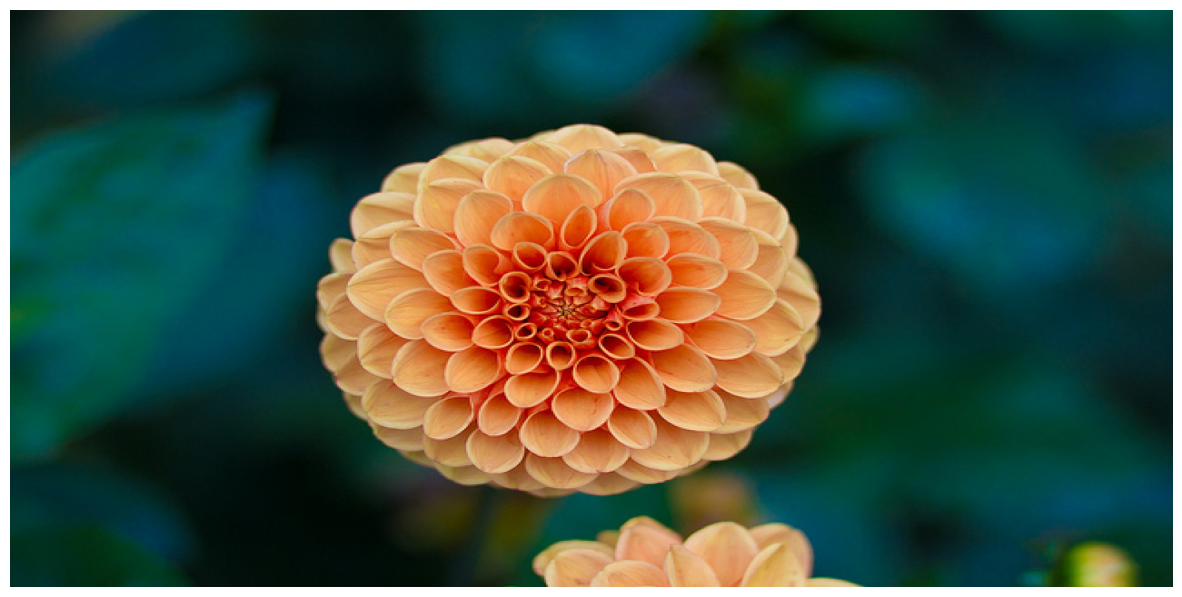

In [6]:
plt.figure(figsize = (15, 7.5))

plt.imshow(IMAGE, aspect = 'auto')

plt.axis('off')

plt.show()

In [7]:
H, W = IMAGE.shape[0], IMAGE.shape[1]

X = IMAGE.reshape(H*W, 3)/255

print('Valor dos Pixels RGB Normalizados:\n')

print(X)

Valor dos Pixels RGB Normalizados:

[[0.00784314 0.0745098  0.05098039]
 [0.01176471 0.07058824 0.05098039]
 [0.02745098 0.07843137 0.05098039]
 ...
 [0.02745098 0.18039216 0.10980392]
 [0.03137255 0.17647059 0.10980392]
 [0.03529412 0.16862745 0.10588235]]


In [8]:
M_HAT = [5, 10, 15]

GMM = {}

for M in M_HAT:

    GMM[f'M = {M}'] = GaussianMixtureModel(X = X, M = M)

    GMM[f'M = {M}'].fit_parameters()


Número Total de Iterações: 37

Erro Absoluto Final: 0.000952483917794549


Número Total de Iterações: 85

Erro Absoluto Final: 0.0009444892063259466


Número Total de Iterações: 97

Erro Absoluto Final: 0.0009665477305366455



In [9]:
X_HAT = {}

for M in M_HAT:

    X_HAT[f'M = {M}'] = GMM[f'M = {M}'].mu[GMM[f'M = {M}'].Z]

In [10]:
IMAGE_HAT = {}

for M in M_HAT:

    IMAGE_HAT[f'M = {M}'] = X_HAT[f'M = {M}'].reshape(H, W, 3)

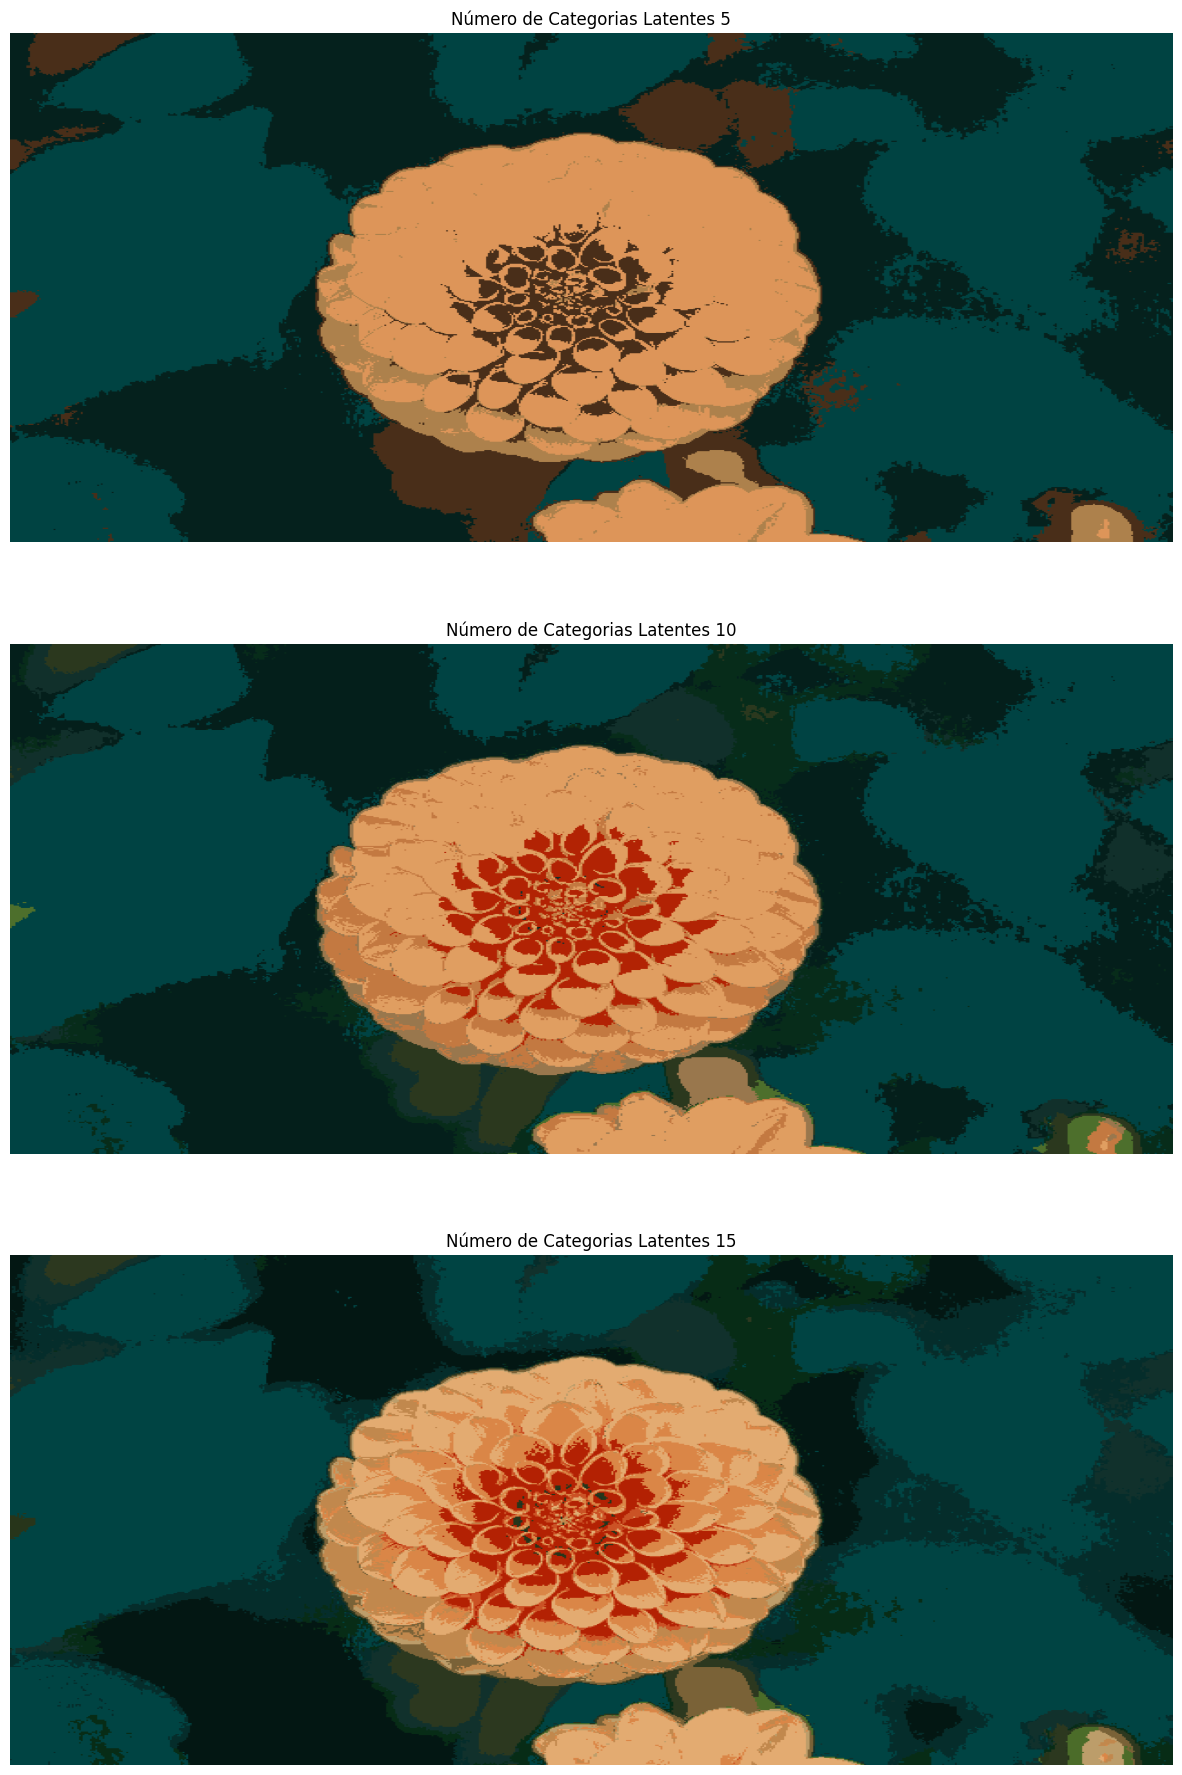

In [11]:
fig, ax = plt.subplots(

    nrows = len(M_HAT), ncols = 1, 
    
    figsize = (15, len(M_HAT)*7.5)

)

ax = ax.ravel()

for i in range(len(M_HAT)):

    ax[i].imshow(IMAGE_HAT[f'M = {M_HAT[i]}'], aspect = 'auto')

    ax[i].set_title(f'Número de Categorias Latentes {M_HAT[i]}')

    ax[i].axis('off')

plt.show()